In [31]:
# M24CA1L306 Data Science Lab - Lab Exercise #19
# Student: Abhinav | MAC25MCA-2002 | S3 MCA (2025-27)
# Dataset: titanic3.csv
# Task: Decision Tree Classifier for passenger survival prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)


In [32]:

# ─────────────────────────────────────────────
# Load and preprocess
# ─────────────────────────────────────────────
df = pd.read_csv("../Datasets/Titanic.csv")
df.columns
# # Keep relevant features
df = df[["Pclass", "Survived", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
df.fillna({"Age": df["Age"].median()}, inplace=True)
df.fillna({"Fare":df["Fare"].median()},inplace=True)
df["Fare"].fillna(df["Fare"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

df["Sex"]      = LabelEncoder().fit_transform(df["Sex"])       # female=0, male=1
df["Embarked"] = LabelEncoder().fit_transform(df["Embarked"])  # C=0, Q=1, S=2

feature_names = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
X = df[feature_names].values
y = df["Survived"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


/tmp/ipykernel_5740/1052789340.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Fare"].fillna(df["Fare"].median(), inplace=True)
/tmp/ipykernel_5740/1052789340.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never wo

In [33]:

# ─────────────────────────────────────────────
# Train Decision Tree
# ─────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=4, random_state=42, criterion="gini")
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)


In [34]:

# ─────────────────────────────────────────────
# Q1: Accuracy
# ─────────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
print("=" * 55)
print("Q1: Accuracy of Decision Tree on Test Data")
print("=" * 55)
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
# Interpretation: The model correctly classifies X% of passengers in the test set.
# A higher accuracy indicates the tree has learned meaningful survival patterns.


Q1: Accuracy of Decision Tree on Test Data
Accuracy: 0.7821 (78.21%)



Q2: Confusion Matrix
True Negatives  (correctly predicted did not survive) : 103
False Positives (predicted survived, actually did not): 7
False Negatives (predicted did not survive, actually did): 32
True Positives  (correctly predicted survived)        : 37

Total correctly classified   : 140
Total incorrectly classified : 39


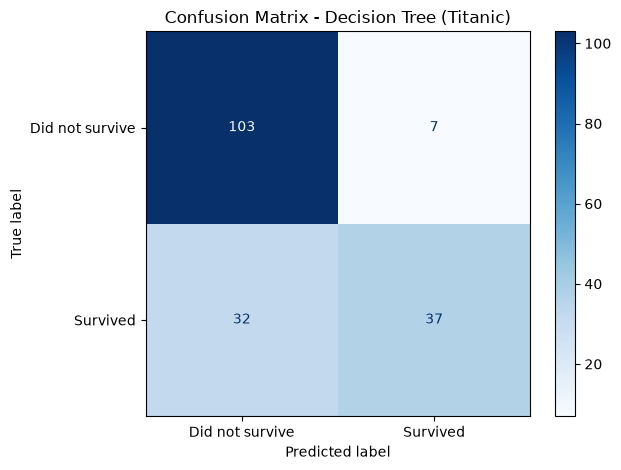

In [35]:

# ─────────────────────────────────────────────
# Q2: Confusion Matrix
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("Q2: Confusion Matrix")
print("=" * 55)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted did not survive) : {tn}")
print(f"False Positives (predicted survived, actually did not): {fp}")
print(f"False Negatives (predicted did not survive, actually did): {fn}")
print(f"True Positives  (correctly predicted survived)        : {tp}")
print(f"\nTotal correctly classified   : {tn + tp}")
print(f"Total incorrectly classified : {fp + fn}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Did not survive", "Survived"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree (Titanic)")
plt.tight_layout()
plt.savefig("../Outputs/lab-19_Output/lab19_confusion_matrix.png", dpi=100)
plt.show()


In [36]:

# ─────────────────────────────────────────────
# Q3 & Q4: Precision, Recall, F1 + Classification Report
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("Q3 & Q4: Classification Report")
print("=" * 55)
report = classification_report(y_test, y_pred,
                                target_names=["Did not survive", "Survived"])
print(report)
# Interpretation:
# Precision - of all predicted survivors, what fraction actually survived
# Recall    - of all actual survivors, what fraction did the model catch
# F1-score  - harmonic mean of precision and recall; useful when classes are imbalanced



Q3 & Q4: Classification Report
                 precision    recall  f1-score   support

Did not survive       0.76      0.94      0.84       110
       Survived       0.84      0.54      0.65        69

       accuracy                           0.78       179
      macro avg       0.80      0.74      0.75       179
   weighted avg       0.79      0.78      0.77       179




Q4: Feature Importance Scores
  Sex         : 0.5763
  Pclass      : 0.1959
  Age         : 0.1161
  Fare        : 0.0540
  Embarked    : 0.0372
  SibSp       : 0.0121
  Parch       : 0.0084


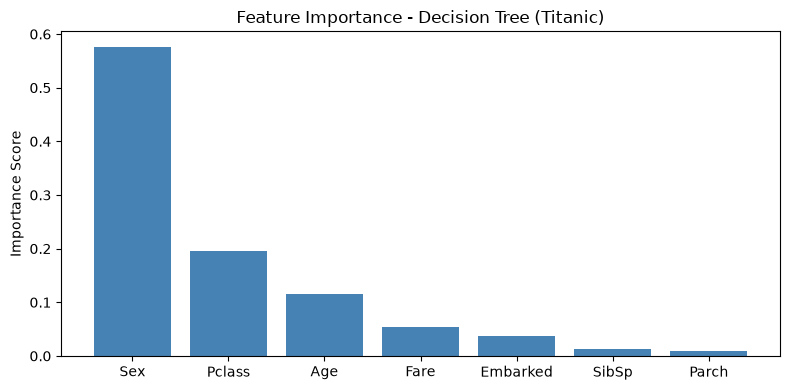

In [37]:

# ─────────────────────────────────────────────
# Q4: Feature Importances
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("Q4: Feature Importance Scores")
print("=" * 55)

importances = dt.feature_importances_
for fname, imp in sorted(zip(feature_names, importances),
                          key=lambda x: x[1], reverse=True):
    print(f"  {fname:12s}: {imp:.4f}")

plt.figure(figsize=(8, 4))
sorted_idx = np.argsort(importances)[::-1]
plt.bar([feature_names[i] for i in sorted_idx],
        [importances[i] for i in sorted_idx], color="steelblue")
plt.title("Feature Importance - Decision Tree (Titanic)")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.savefig("../Outputs/lab-19_Output/lab19_feature_importance.png", dpi=100)
plt.show()

# Findings: sex and pclass are typically the most influential features,
# reflecting the "women and children first" evacuation policy.


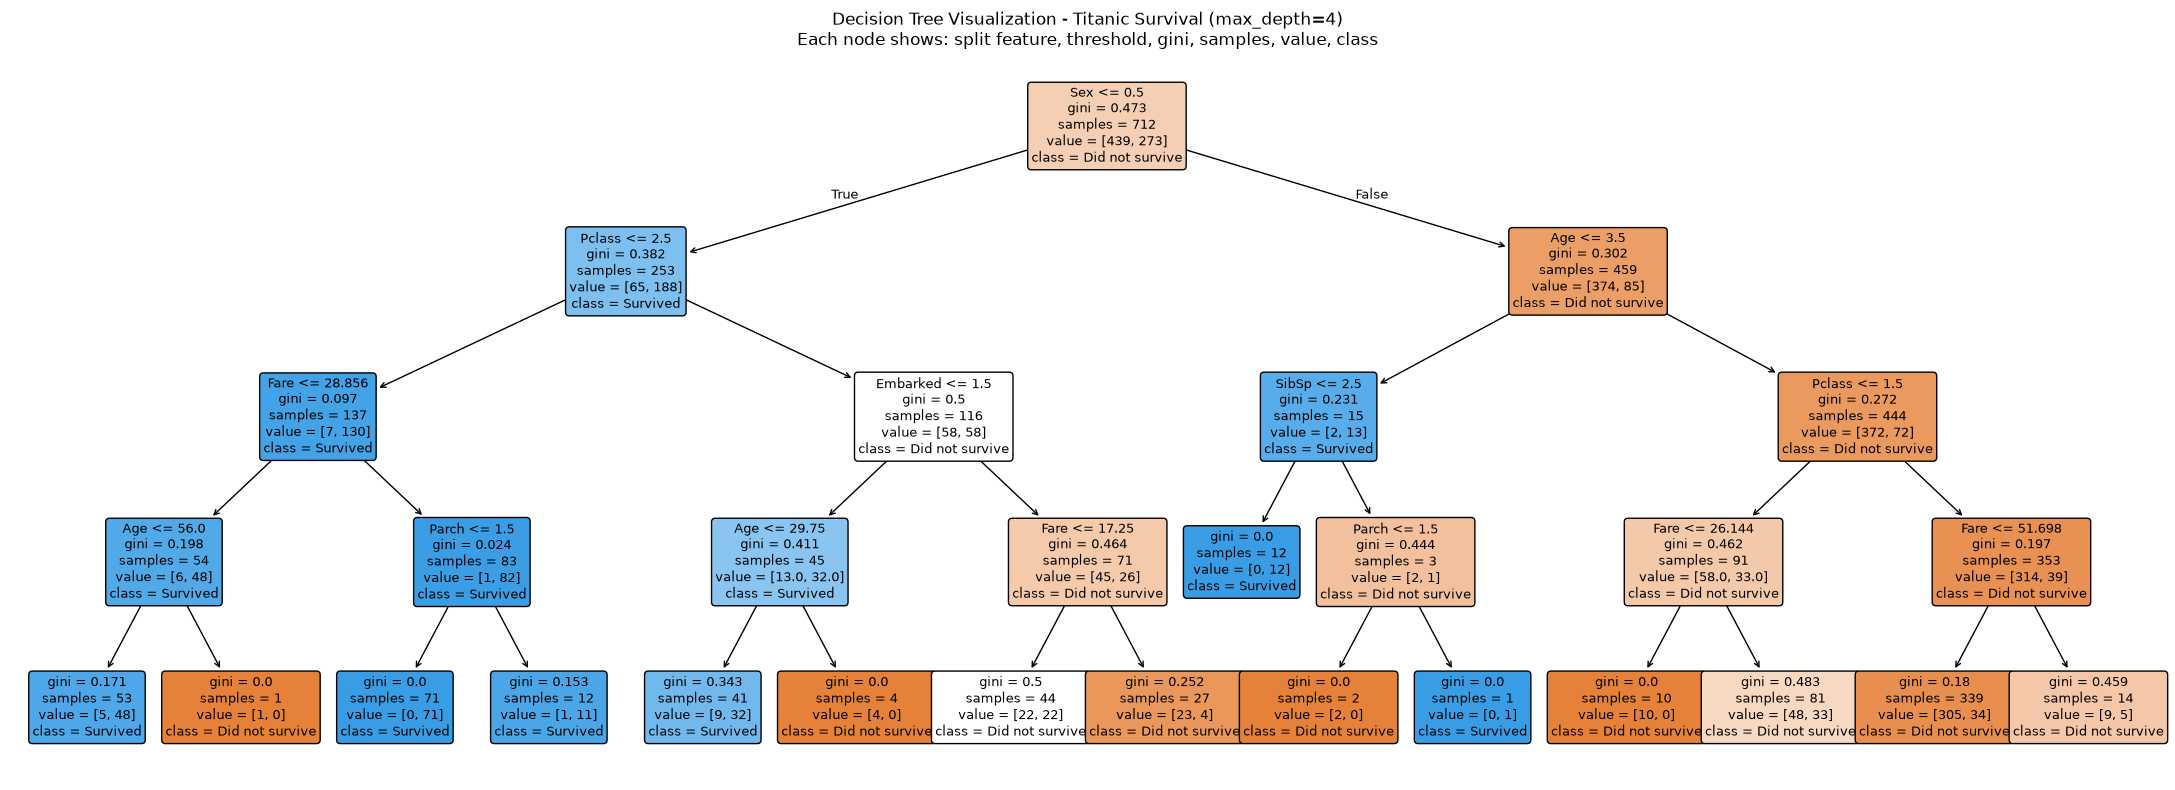


Decision path explanation - Female passenger in 1st class:
  Root node splits on sex (female=0, male=1)
  sex <= 0.5 -> goes LEFT (female branch)
  Further splits may check pclass or fare
  A 1st class female almost always reaches a 'Survived' leaf node
  This reflects the historical evacuation priority given to women in 1st class


In [38]:

# ─────────────────────────────────────────────
# Q5: Visualize Decision Tree + explain one path
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt,
    feature_names=feature_names,
    class_names=["Did not survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
plt.title("Decision Tree Visualization - Titanic Survival (max_depth=4)\nEach node shows: split feature, threshold, gini, samples, value, class")
plt.tight_layout()
plt.savefig("../Outputs/lab-19_Output/lab19_decision_tree.png", dpi=100, bbox_inches="tight")
plt.show()

print("\nDecision path explanation - Female passenger in 1st class:")
print("  Root node splits on sex (female=0, male=1)")
print("  sex <= 0.5 -> goes LEFT (female branch)")
print("  Further splits may check pclass or fare")
print("  A 1st class female almost always reaches a 'Survived' leaf node")
print("  This reflects the historical evacuation priority given to women in 1st class")